## Imports

In [1]:
!pip install -r requirements.txt -q
!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu118
!pip install accelerate -U

Looking in indexes: https://download.pytorch.org/whl/cu118


In [2]:
%pip install torch_geometric

Note: you may need to restart the kernel to use updated packages.


## PHASE 1 — Improved SGC Baseline

Improvements over the vanilla baseline:
- **Sigmoid output** constrains predictions to [0, 1] naturally.
- **Dropout** (p=0.3) in MLP to reduce overfitting on the small dataset.
- **AdamW** optimizer with weight decay (1e-3).
- **SmoothL1 (Huber) loss** as default; optional **WeightedMAE** (`USE_WEIGHTED_LOSS=True`).
- **Early stopping** (patience=20 epochs) with best-weight restoration per fold.
- Per-fold logging: best epoch, best val MAE, and all `compute_metrics` outputs.


In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

from utils.MatrixVectorizer import MatrixVectorizer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DATA_DIR = "data"
TRAIN_LR_PATH = os.path.join(DATA_DIR, "lr_train.csv")
TRAIN_HR_PATH = os.path.join(DATA_DIR, "hr_train.csv")
TEST_LR_PATH  = os.path.join(DATA_DIR, "lr_test.csv")

EPOCHS = 200
LR = 1e-3
BATCH_SIZE = 16
K_PROP = 2
HIDDEN_DIM = 128
MLP_DIM = 256
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# PHASE 1 hyperparameters
DROPOUT          = 0.3    # MLP dropout probability
WEIGHT_DECAY     = 1e-3   # AdamW weight decay
PATIENCE         = 20     # early-stopping patience (epochs without improvement)
ALPHA            = 5.0    # WeightedMAE alpha: w = 1 + alpha * y_true
USE_WEIGHTED_LOSS = False  # True → WeightedMAELoss, False → L1Loss (pure MAE)
USE_LR_MAX_NORM  = False  # True → per-subject max-normalisation of LR matrices

# PHASE 2 hyperparameters
MODEL_TYPE    = "sgc"  # "sgc" | "lowrank"
LOWRANK_DIM   = 32     # low-rank embedding dim d  (A_hat = Z @ Z^T)

# PHASE 3 hyperparameters
SEEDS         = [42, 123, 999]  # seeds for seed-averaging
RUN_SEED_AVG  = True            # set False to skip multi-seed runs (saves time)


In [4]:
%run utils/reproducibility.py

# Sync notebook constants with reproducibility.py
DEVICE = device
RANDOM_SEED = random_seed

CUDA is available. Using GPU.


In [ ]:
def sanitize_vectors(x: np.ndarray) -> np.ndarray:
    # Ensure non-negative and finite values.
    x = np.nan_to_num(x)
    x[x < 0] = 0
    return x

def load_train_data(lr_path: str, hr_path: str):
    lr_vecs = pd.read_csv(lr_path).to_numpy(dtype=np.float32)
    hr_vecs = pd.read_csv(hr_path).to_numpy(dtype=np.float32)

    lr_vecs = sanitize_vectors(lr_vecs)
    hr_vecs = sanitize_vectors(hr_vecs)
    return lr_vecs, hr_vecs

def load_test_lr(path: str) -> np.ndarray | None:
    if not os.path.exists(path):
        print(f"[Phase 3] WARNING: test file not found: {path}. Skipping test inference.")
        return None
    vecs = pd.read_csv(path).to_numpy(dtype=np.float32)
    return sanitize_vectors(vecs)

def remove_outlier_subjects(lr_vecs: np.ndarray, hr_vecs: np.ndarray, n_std: float = 3.0):
    """Remove subjects whose mean HR edge weight is more than n_std std-devs above the mean."""
    per_subject_mean = hr_vecs.mean(axis=1)
    threshold = per_subject_mean.mean() + n_std * per_subject_mean.std()
    keep = per_subject_mean <= threshold
    n_removed = int((~keep).sum())
    if n_removed:
        print(f"[outlier filter] removed {n_removed} subject(s) with mean HR > {threshold:.3f}: "
              f"indices {np.where(~keep)[0].tolist()}")
    return lr_vecs[keep], hr_vecs[keep]


def vectors_to_matrices(vectors: np.ndarray, matrix_size: int) -> np.ndarray:
    mats = [MatrixVectorizer.anti_vectorize(v, matrix_size) for v in vectors]
    return np.stack(mats, axis=0)


def normalize_lr_mats(mats: np.ndarray) -> np.ndarray:
    """Per-subject max-normalization: scale each LR adjacency to [0, 1].

    The raw LR edge weights span [0, 12719], and test subjects have ~50% higher
    mean weight than train subjects.  Without this, the SGC propagation produces
    activations large enough to saturate the output sigmoid to 1.0 on test data.
    Dividing each subject by its own max decouples the model from absolute scale
    while preserving the relative connectivity pattern.
    """
    out = mats.copy()
    for i in range(len(out)):
        max_val = float(out[i].max())
        if max_val > 0.0:
            out[i] /= max_val
    return out


def normalize_adj_batch(adj: torch.Tensor) -> torch.Tensor:
    b, n, _ = adj.shape
    eye = torch.eye(n, device=adj.device).unsqueeze(0).expand(b, -1, -1)
    adj = adj + eye
    degree = adj.sum(dim=2)
    d_inv_sqrt = degree.pow(-0.5)
    d_inv_sqrt[d_inv_sqrt == float("inf")] = 0.0
    adj_norm = adj * d_inv_sqrt.unsqueeze(2) * d_inv_sqrt.unsqueeze(1)
    return adj_norm


In [6]:
# PHASE 1: improved SGC baseline
class SGCBaseline(nn.Module):
    """SGC (Simple Graph Convolution) baseline with Phase-1 improvements:
    - Linear output head (no sigmoid); predictions clipped to [0,1] at inference.
    - Dropout in MLP for regularisation.
    """
    def __init__(
        self,
        lr_nodes: int = 160,
        k_prop: int = 2,
        hidden_dim: int = 128,
        mlp_dim: int = 256,
        out_dim: int = 35778,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.lr_nodes = lr_nodes
        self.k_prop = k_prop
        self.node_proj = nn.Linear(lr_nodes, hidden_dim)
        self.mlp = nn.Sequential(
            nn.Linear(lr_nodes * hidden_dim, mlp_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, out_dim),
        )

    def forward(self, adj_lr: torch.Tensor) -> torch.Tensor:
        adj_norm = normalize_adj_batch(adj_lr)
        # SGC propagation: X' = (A_norm)^K X
        x = adj_lr
        for _ in range(self.k_prop):
            x = torch.bmm(adj_norm, x)
        h = self.node_proj(x)
        h_flat = h.reshape(h.size(0), -1)
        return self.mlp(h_flat)


## PHASE 2 — Low-Rank HR Generator (A_hat = sigmoid(Z @ Z^T))

An alternative model that predicts the HR adjacency via low-rank node embeddings:
- Encode LR adjacency to a graph-level vector `g` (SGC propagation + mean-pool).
- Decode `g` → node embeddings `Z` of shape `(B, 268, d)`.
- Produce `A_hat = sigmoid(Z @ Z^T)`, enforce symmetry and zero diagonal, vectorize.

Switch between models with `MODEL_TYPE = "sgc"` or `"lowrank"`.


In [7]:
# PHASE 2: Low-rank HR generator
class LowRankHRGenerator(nn.Module):
    """Predicts HR adjacency as A_hat = Z @ Z^T (linear), vectorized to length 35778.

    Architecture:
      1. LR encoder: SGC propagation (K steps) → mean-pool over nodes → vector g.
      2. Decoder: g → Z of shape (B, 268, d)  via MLP + reshape.
      3. A_hat = Z @ Z^T; symmetrised + zero-diagonal; predictions clipped at inference.
      4. Differentiable upper-triangle extraction matching MatrixVectorizer column-first order.

    forward() returns shape (B, 35778) — same contract as SGCBaseline.
    """
    HR_NODES   = 268
    HR_VEC_DIM = 35778

    def __init__(
        self,
        lr_nodes:   int   = 160,
        k_prop:     int   = 2,
        hidden_dim: int   = 128,
        d:          int   = 32,
        dropout:    float = 0.3,
    ):
        super().__init__()
        self.lr_nodes = lr_nodes
        self.k_prop   = k_prop
        self.d        = d

        # Node-level projection (shared across LR positions)
        self.node_proj = nn.Linear(lr_nodes, hidden_dim)

        # MLP: global summary  →  268 * d
        self.decoder = nn.Sequential(
            nn.Linear(lr_nodes * hidden_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, self.HR_NODES * d),
        )

        # Precompute upper-triangle index tensors in MatrixVectorizer
        #    column-first order so extraction is differentiable and consistent 
        rows, cols = [], []
        for col in range(self.HR_NODES):
            for row in range(col):   # row < col
                rows.append(row)
                cols.append(col)
        # Registered as buffers so they move to the right device automatically
        self.register_buffer("triu_row", torch.tensor(rows, dtype=torch.long))
        self.register_buffer("triu_col", torch.tensor(cols, dtype=torch.long))
        assert len(rows) == self.HR_VEC_DIM, "Index pre-computation mismatch."

    def forward(self, adj_lr: torch.Tensor) -> torch.Tensor:
        # 1. SGC propagation over LR graph
        adj_norm = normalize_adj_batch(adj_lr)
        x = adj_lr                                   # (B, 160, 160)
        for _ in range(self.k_prop):
            x = torch.bmm(adj_norm, x)

        h = self.node_proj(x)                        # (B, 160, hidden_dim)
        g = h.reshape(h.size(0), -1)                 # (B, 160*hidden_dim)

        # 2. Decode to HR node embeddings
        Z = self.decoder(g).view(-1, self.HR_NODES, self.d)  # (B, 268, d)

        # 3. Low-rank adjacency (linear — no sigmoid; clipped at inference)
        A_hat = torch.bmm(Z, Z.transpose(1, 2))              # (B, 268, 268)

        # Enforce symmetry + zero diagonal (all differentiable)
        A_hat = (A_hat + A_hat.transpose(1, 2)) * 0.5
        diag  = torch.eye(self.HR_NODES, device=A_hat.device, dtype=torch.bool)
        A_hat = A_hat.masked_fill(diag.unsqueeze(0), 0.0)

        # 4. Differentiable upper-triangle extraction
        #    Indexes matching MatrixVectorizer.vectorize column-first order  
        vec = A_hat[:, self.triu_row, self.triu_col]   # (B, 35778)
        return vec


def build_model(model_type: str = "sgc") -> nn.Module:
    """Factory: instantiates the chosen model with the current global hyper-params."""
    if model_type == "sgc":
        return SGCBaseline(
            lr_nodes=160, k_prop=K_PROP, hidden_dim=HIDDEN_DIM,
            mlp_dim=MLP_DIM, out_dim=35778, dropout=DROPOUT,
        )
    elif model_type == "lowrank":
        return LowRankHRGenerator(
            lr_nodes=160, k_prop=K_PROP, hidden_dim=HIDDEN_DIM,
            d=LOWRANK_DIM, dropout=DROPOUT,
        )
    else:
        raise ValueError(f"Unknown MODEL_TYPE: {model_type!r}. Use 'sgc' or 'lowrank'.")


In [8]:
import copy
from joblib import Parallel, delayed
from utils.training import compute_metrics

# PHASE 1: loss functions

class WeightedMAELoss(nn.Module):
    """Element-wise MAE weighted by w = 1 + alpha * y_true.

    Encourages the model to be more accurate on high-weight (high-value) edges.
    Compatible with GPU tensors and arbitrary batch dimensions.
    """
    def __init__(self, alpha: float = 5.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        weights = 1.0 + self.alpha * target.detach()   # no grad through weights
        return (weights * (pred - target).abs()).mean()


def get_loss_fn(use_weighted: bool = False, alpha: float = 5.0) -> nn.Module:
    """Return the configured loss function."""
    if use_weighted:
        return WeightedMAELoss(alpha=alpha)
    return nn.L1Loss()   # pure MAE


# Training helpers

def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    running = 0.0
    for adj_lr, hr_vec in loader:
        adj_lr = adj_lr.to(DEVICE)
        hr_vec = hr_vec.to(DEVICE)

        optimizer.zero_grad()
        pred = model(adj_lr)
        loss = loss_fn(pred, hr_vec)
        loss.backward()
        optimizer.step()

        running += loss.item() * adj_lr.size(0)
    return running / len(loader.dataset)


def val_epoch(model, loader) -> float:
    """Compute mean absolute error on the validation split (no gradient)."""
    model.eval()
    mae_loss = nn.L1Loss()
    total, n = 0.0, 0
    with torch.no_grad():
        for adj_lr, hr_vec in loader:
            adj_lr = adj_lr.to(DEVICE)
            hr_vec = hr_vec.to(DEVICE)
            pred   = model(adj_lr)
            total += mae_loss(pred, hr_vec).item() * adj_lr.size(0)
            n     += adj_lr.size(0)
    return total / n


def predict(model, loader) -> np.ndarray:
    """Run inference and return predictions clipped to [0, 1] as a numpy array."""
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            # Support loaders with or without HR labels
            adj_lr = (batch[0] if isinstance(batch, (list, tuple)) else batch).to(DEVICE)
            pred   = model(adj_lr).cpu().numpy()
            pred   = np.clip(pred, 0.0, 1.0)   # clip linear output to valid range
            preds.append(pred)
    return np.concatenate(preds, axis=0)


def postprocess(pred_vecs: np.ndarray) -> np.ndarray:
    """Clip predictions to [0, 1] and ensure no NaN/Inf."""
    pred_vecs = np.nan_to_num(pred_vecs)
    return np.clip(pred_vecs, 0.0, 1.0)


def save_predictions_csv(pred_vecs: np.ndarray, out_path: str):
    flat = pred_vecs.flatten()
    ids = np.arange(1, len(flat) + 1, dtype=np.int32)

    df = pd.DataFrame({
        "ID": ids,
        "Predicted": flat
    })

    df.to_csv(out_path, index=False)


In [9]:
# PHASE 1: 3-fold CV with early stopping, AdamW and improved loss 

lr_vecs_raw, hr_vecs_raw = load_train_data(TRAIN_LR_PATH, TRAIN_HR_PATH)

# Sanity checks on raw loaded data (before outlier removal)
assert lr_vecs_raw.shape == (167, 12720), f"Unexpected LR train shape: {lr_vecs_raw.shape}"
assert hr_vecs_raw.shape == (167, 35778), f"Unexpected HR train shape: {hr_vecs_raw.shape}"
assert lr_vecs_raw.min() >= -1e-6,       f"LR train min {lr_vecs_raw.min():.6f} is below 0"
assert lr_vecs_raw.max() <= 1 + 1e-6,    f"LR train max {lr_vecs_raw.max():.6f} is above 1"
assert hr_vecs_raw.min() >= -1e-6,       f"HR train min {hr_vecs_raw.min():.6f} is below 0"
assert hr_vecs_raw.max() <= 1 + 1e-6,    f"HR train max {hr_vecs_raw.max():.6f} is above 1"
print(f"[sanity] LR train : shape={lr_vecs_raw.shape}  range=[{lr_vecs_raw.min():.4f}, {lr_vecs_raw.max():.4f}]")
print(f"[sanity] HR train : shape={hr_vecs_raw.shape}  range=[{hr_vecs_raw.min():.4f}, {hr_vecs_raw.max():.4f}]")

lr_vecs, hr_vecs = lr_vecs_raw, hr_vecs_raw
lr_vecs, hr_vecs = remove_outlier_subjects(lr_vecs, hr_vecs)

lr_mats = vectors_to_matrices(lr_vecs, 160).astype(np.float32)
if USE_LR_MAX_NORM:
    lr_mats = normalize_lr_mats(lr_mats)
hr_vecs = hr_vecs.astype(np.float32)

print("LR vectors:", lr_vecs.shape)
print("HR vectors:", hr_vecs.shape)
print("LR matrices:", lr_mats.shape)
print(f"\nModel type : {MODEL_TYPE}")
print(f"Loss       : {'WeightedMAE' if USE_WEIGHTED_LOSS else 'L1 (pure MAE)'}")
print(f"LR max-norm: {USE_LR_MAX_NORM}")
print(f"Optimizer  : AdamW  lr={LR}  weight_decay={WEIGHT_DECAY}")
print(f"Early stop : patience={PATIENCE}  max_epochs={EPOCHS}")

kfold = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
all_fold_metrics = []

oof_preds_list = []
oof_gts_list   = []

loss_fn = get_loss_fn(USE_WEIGHTED_LOSS, ALPHA)

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(lr_mats), start=1):
    print(f"\n{'='*50}")
    print(f"  Fold {fold_idx}/3")
    print(f"{'='*50}")

    train_adj = torch.from_numpy(lr_mats[train_idx])
    train_hr  = torch.from_numpy(hr_vecs[train_idx])
    val_adj   = torch.from_numpy(lr_mats[val_idx])
    val_hr    = torch.from_numpy(hr_vecs[val_idx])

    # Worker seed fn: ensures each DataLoader worker is reproducible 
    def worker_init_fn(worker_id):
        np.random.seed(RANDOM_SEED + worker_id)

    train_loader = DataLoader(
        TensorDataset(train_adj, train_hr),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=False,
        worker_init_fn=worker_init_fn,
    )
    val_loader = DataLoader(
        TensorDataset(val_adj, val_hr),
        batch_size=BATCH_SIZE, shuffle=False, drop_last=False,
    )

    # Model + optimiser
    model = build_model(MODEL_TYPE).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
    )

    # Training loop with early stopping
    best_val_mae   = float("inf")
    best_epoch     = 0
    patience_count = 0
    best_weights   = None   # keep best weights in memory

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn)
        val_mae    = val_epoch(model, val_loader)

        if epoch % 20 == 0:
            print(f"  Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_MAE={val_mae:.6f}")

        # Early stopping check
        if val_mae < best_val_mae - 1e-7:
            best_val_mae  = val_mae
            best_epoch    = epoch
            best_weights  = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"  ↳ Early stopping at epoch {epoch} "
                      f"(no improvement for {PATIENCE} epochs).")
                break

    # Restore best weights before predicting
    model.load_state_dict(best_weights)
    print(f"\n  ✓ Best epoch: {best_epoch}  |  Best val MAE: {best_val_mae:.6f}")

    preds = predict(model, val_loader)
    preds = postprocess(preds)

    # Store OOF predictions in memory
    oof_preds_list.append(preds)
    oof_gts_list.append(hr_vecs[val_idx])

    # Save fold predictions for submission.
    fold_csv = os.path.join(OUTPUT_DIR, f"predictions_fold_{fold_idx}.csv")
    save_predictions_csv(preds, fold_csv)

    metrics = compute_metrics(preds, hr_vecs[val_idx], sanitize_fn=sanitize_vectors)
    all_fold_metrics.append(metrics)

    print("\n  Fold metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.6f}")

# Summary across folds
metric_names = list(all_fold_metrics[0].keys())
means = [np.mean([m[n] for m in all_fold_metrics]) for n in metric_names]
stds  = [np.std( [m[n] for m in all_fold_metrics]) for n in metric_names]

print("\n" + "="*50)
print("  3-Fold CV Summary (mean ± std)")
print("="*50)
for name, mu, sigma in zip(metric_names, means, stds):
    print(f"  {name:12s}: {mu:.6f} ± {sigma:.6f}")


[sanity] LR train : shape=(167, 12720)  range=[0.0000, 0.9990]
[sanity] HR train : shape=(167, 35778)  range=[0.0000, 0.9999]
[outlier filter] removed 2 subject(s) with mean HR > 0.434: indices [35, 71]
LR vectors: (165, 12720)
HR vectors: (165, 35778)
LR matrices: (165, 160, 160)

Model type : sgc
Loss       : L1 (pure MAE)
LR max-norm: False
Optimizer  : AdamW  lr=0.001  weight_decay=0.001
Early stop : patience=20  max_epochs=200

  Fold 1/3
  Epoch 020 | train_loss=0.198641 | val_MAE=0.194563
  Epoch 040 | train_loss=0.164069 | val_MAE=0.161510
  Epoch 060 | train_loss=0.147486 | val_MAE=0.146239
  Epoch 080 | train_loss=0.140327 | val_MAE=0.139915
  Epoch 100 | train_loss=0.137588 | val_MAE=0.137656
  Epoch 120 | train_loss=0.136737 | val_MAE=0.137065
  Epoch 140 | train_loss=0.136560 | val_MAE=0.136989
  ↳ Early stopping at epoch 156 (no improvement for 20 epochs).

  ✓ Best epoch: 136  |  Best val MAE: 0.136988

  Fold metrics:
  MAE: 0.136986
  PCC: 0.614552
  JSD: 0.294632
  MA

Figure saved to figs/improved_cv_metrics.png


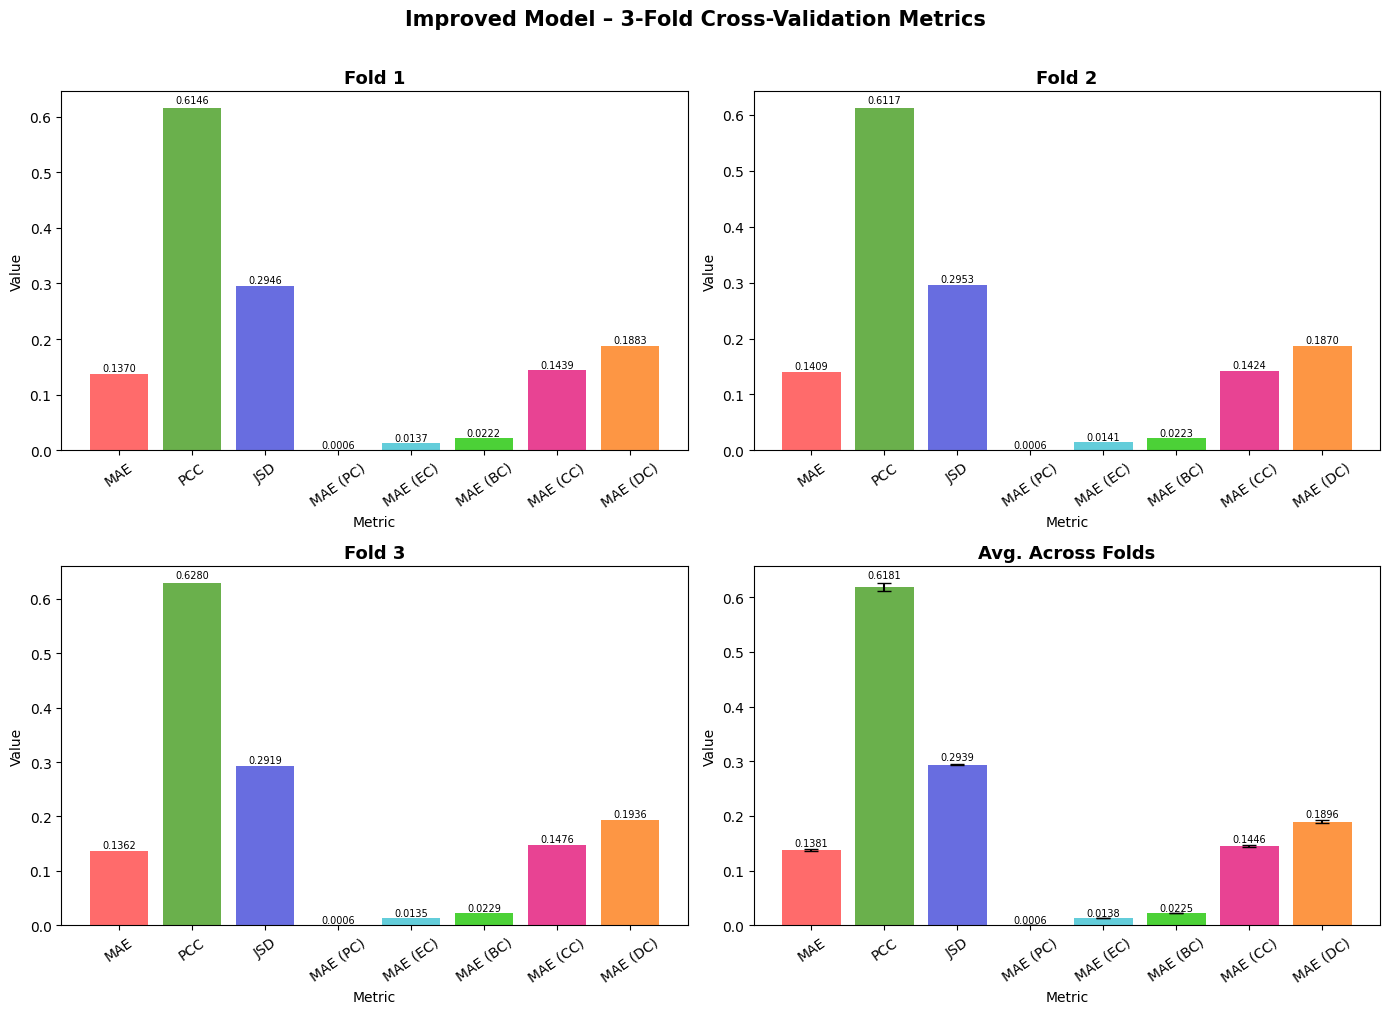

In [10]:
from utils.plot_chart import plot_fold_metrics

os.makedirs("figs", exist_ok=True)

fig = plot_fold_metrics(
    all_fold_metrics,
    title="Improved Model – 3-Fold Cross-Validation Metrics",
    save_path="figs/improved_cv_metrics.png",
)
plt.show()


In [11]:
from sklearn.metrics import mean_absolute_error

# OOF flatten MAE — concatenate all fold predictions in memory
oof_preds = np.concatenate(oof_preds_list, axis=0)  # (N_total, hr_vec_dim)
oof_gts   = np.concatenate(oof_gts_list,   axis=0)  # (N_total, hr_vec_dim)

oof_flat_mae = mean_absolute_error(oof_gts.flatten(), oof_preds.flatten())
print(f"OOF Flatten MAE (all folds concatenated): {oof_flat_mae:.6f}")
print(f"  Total subjects in OOF: {oof_preds.shape[0]}")


OOF Flatten MAE (all folds concatenated): 0.138054
  Total subjects in OOF: 165


## PHASE 3 — Ensembling Utilities

Three outputs are generated here:
1. **`outputs/submission_foldavg.csv`** — single-seed (42), average of 3-fold test predictions.
2. **`outputs/submission_foldavg_seedavg.csv`** — average over `SEEDS` × 3 folds (controlled by `RUN_SEED_AVG`).

> If `data/lr_test.csv` is missing, Phase 3 skips with a warning.
> Set `RUN_SEED_AVG = False` to skip multi-seed runs and save time.


In [12]:
# PHASE 3: helpers
def run_cv_and_get_test_preds(
    lr_mats_tr: np.ndarray,
    hr_vecs_tr:  np.ndarray,
    lr_mats_te:  np.ndarray,
    seed:        int,
    model_type:  str = None,
) -> np.ndarray:
    """Train one full 3-fold CV for a given seed; return averaged test predictions.

    Parameters
    ----------
    lr_mats_tr / hr_vecs_tr : full training data.
    lr_mats_te              : test LR matrices (already pre-processed).
    seed                    : random seed for KFold + torch.
    model_type              : overrides global MODEL_TYPE if not None.

    Returns
    -------
    test_preds_avg : (N_test, 35778) – fold-averaged test predictions.
    """
    if model_type is None:
        model_type = MODEL_TYPE

    # Reset seeds for reproducibility
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    kf      = KFold(n_splits=3, shuffle=True, random_state=seed)
    loss_fn = get_loss_fn(USE_WEIGHTED_LOSS, ALPHA)

    test_tensor = torch.from_numpy(lr_mats_te)
    # Dummy labels (zeros) so TensorDataset works with the shared predict() helper
    dummy_hr    = torch.zeros(len(lr_mats_te), hr_vecs_tr.shape[1])
    test_loader = DataLoader(
        TensorDataset(test_tensor, dummy_hr),
        batch_size=BATCH_SIZE, shuffle=False,
    )

    fold_test_preds = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(lr_mats_tr), start=1):
        print(f"  [seed={seed}] Fold {fold_idx}/3 ...", end=" ", flush=True)

        train_loader = DataLoader(
            TensorDataset(
                torch.from_numpy(lr_mats_tr[train_idx]),
                torch.from_numpy(hr_vecs_tr[train_idx]),
            ),
            batch_size=BATCH_SIZE, shuffle=True, drop_last=False,
        )
        val_loader = DataLoader(
            TensorDataset(
                torch.from_numpy(lr_mats_tr[val_idx]),
                torch.from_numpy(hr_vecs_tr[val_idx]),
            ),
            batch_size=BATCH_SIZE, shuffle=False,
        )

        model     = build_model(model_type).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        best_val_mae, best_epoch = float("inf"), 0
        patience_count, best_weights = 0, None

        for epoch in range(1, EPOCHS + 1):
            train_epoch(model, train_loader, optimizer, loss_fn)
            v_mae = val_epoch(model, val_loader)

            if v_mae < best_val_mae - 1e-7:
                best_val_mae, best_epoch = v_mae, epoch
                best_weights = copy.deepcopy(model.state_dict())
                patience_count = 0
            else:
                patience_count += 1
                if patience_count >= PATIENCE:
                    break

        model.load_state_dict(best_weights)
        print(f"best_epoch={best_epoch}  val_MAE={best_val_mae:.6f}")

        fold_preds = postprocess(predict(model, test_loader))
        fold_test_preds.append(fold_preds)

    # Average across 3 folds
    return np.mean(fold_test_preds, axis=0)


# PHASE 3.1: Single-seed fold-averaged test submission

test_lr_vecs = load_test_lr(TEST_LR_PATH)

if test_lr_vecs is not None:
    # Sanity checks on test data
    assert test_lr_vecs.shape == (112, 12720), f"Unexpected LR test shape: {test_lr_vecs.shape}"
    assert test_lr_vecs.min() >= -1e-6,       f"LR test min {test_lr_vecs.min():.6f} is below 0"
    assert test_lr_vecs.max() <= 1 + 1e-6,    f"LR test max {test_lr_vecs.max():.6f} is above 1"
    print(f"[sanity] LR test  : shape={test_lr_vecs.shape}  range=[{test_lr_vecs.min():.4f}, {test_lr_vecs.max():.4f}]")

    test_lr_mats = vectors_to_matrices(test_lr_vecs, 160).astype(np.float32)
    if USE_LR_MAX_NORM:
        test_lr_mats = normalize_lr_mats(test_lr_mats)
    print(f"\n[Phase 3.1] Generating fold-averaged submission  (seed={RANDOM_SEED}) ...")
    test_preds_foldavg = run_cv_and_get_test_preds(
        lr_mats, hr_vecs, test_lr_mats, seed=RANDOM_SEED,
    )
    sub_path = os.path.join(OUTPUT_DIR, "submission_foldavg.csv")
    save_predictions_csv(test_preds_foldavg, sub_path)
    print(f"  ✓ Saved fold-averaged submission → {sub_path}")
    print(f"    Test predictions shape: {test_preds_foldavg.shape}")
    print(f"    Value range: [{test_preds_foldavg.min():.4f}, {test_preds_foldavg.max():.4f}]")
else:
    test_lr_mats = None
    test_preds_foldavg = None
    print("[Phase 3.1] Skipped (no test file).")


[sanity] LR test  : shape=(112, 12720)  range=[0.0000, 0.9945]

[Phase 3.1] Generating fold-averaged submission  (seed=42) ...
  [seed=42] Fold 1/3 ... best_epoch=136  val_MAE=0.136988
  [seed=42] Fold 2/3 ... best_epoch=194  val_MAE=0.140940
  [seed=42] Fold 3/3 ... best_epoch=150  val_MAE=0.136242
  ✓ Saved fold-averaged submission → outputs/submission_foldavg.csv
    Test predictions shape: (112, 35778)
    Value range: [0.0000, 0.9375]


In [13]:
# PHASE 3.2: Multi-seed seed-averaged test submission
# Controlled by RUN_SEED_AVG flag; can be disabled to save runtime.

if test_lr_mats is not None and RUN_SEED_AVG:
    print(f"\n[Phase 3.2] Seed-averaging over seeds={SEEDS} ...")
    all_seed_preds = []

    for seed in SEEDS:
        print(f"\n  Seed {seed} ")
        seed_preds = run_cv_and_get_test_preds(
            lr_mats, hr_vecs, test_lr_mats, seed=seed,
        )
        # Also save per-seed fold-averaged prediction for traceability
        per_seed_path = os.path.join(OUTPUT_DIR, f"submission_seed{seed}_foldavg.csv")
        save_predictions_csv(seed_preds, per_seed_path)
        print(f"  ✓ Saved per-seed submission → {per_seed_path}")
        all_seed_preds.append(seed_preds)

    # Average across all seeds
    test_preds_seedavg = postprocess(np.mean(all_seed_preds, axis=0))
    seedavg_path = os.path.join(OUTPUT_DIR, "submission_foldavg_seedavg.csv")
    save_predictions_csv(test_preds_seedavg, seedavg_path)
    print(f"\n  ✓ Saved seed-averaged submission → {seedavg_path}")
    print(f"    Averaged over {len(SEEDS)} seeds × 3 folds = {len(SEEDS)*3} models.")
    print(f"    Value range: [{test_preds_seedavg.min():.4f}, {test_preds_seedavg.max():.4f}]")

elif test_lr_mats is None:
    print("[Phase 3.2] Skipped (no test file).")
else:
    print("[Phase 3.2] Skipped (RUN_SEED_AVG=False).")

print("\n[Phase 3] Done.  Files written to outputs/:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, fname)
    size_kb = os.path.getsize(path) / 1024
    print(f"  {fname:<45s}  ({size_kb:.1f} KB)")



[Phase 3.2] Seed-averaging over seeds=[42, 123, 999] ...

  Seed 42 
  [seed=42] Fold 1/3 ... best_epoch=136  val_MAE=0.136988
  [seed=42] Fold 2/3 ... best_epoch=194  val_MAE=0.140940
  [seed=42] Fold 3/3 ... best_epoch=150  val_MAE=0.136242
  ✓ Saved per-seed submission → outputs/submission_seed42_foldavg.csv

  Seed 123 
  [seed=123] Fold 1/3 ... best_epoch=147  val_MAE=0.139175
  [seed=123] Fold 2/3 ... best_epoch=200  val_MAE=0.138705
  [seed=123] Fold 3/3 ... best_epoch=138  val_MAE=0.136479
  ✓ Saved per-seed submission → outputs/submission_seed123_foldavg.csv

  Seed 999 
  [seed=999] Fold 1/3 ... best_epoch=138  val_MAE=0.137598
  [seed=999] Fold 2/3 ... best_epoch=142  val_MAE=0.135656
  [seed=999] Fold 3/3 ... best_epoch=185  val_MAE=0.140653
  ✓ Saved per-seed submission → outputs/submission_seed999_foldavg.csv

  ✓ Saved seed-averaged submission → outputs/submission_foldavg_seedavg.csv
    Averaged over 3 seeds × 3 folds = 9 models.
    Value range: [0.0000, 0.9401]

[Pha

In [14]:
assert test_preds_seedavg.shape == (112, 35778)

import pandas as pd
df = pd.read_csv("outputs/submission_foldavg_seedavg.csv")
assert df.shape[0] == 4007136
assert df["ID"].iloc[0] == 1 and df["ID"].iloc[-1] == 4007136